# 5. Classification, calibration and deployment

Notebooks 1–4 built a regression model. This one covers what changes for
classification — where the default 0.5 cutoff is almost never right and a
probability is usually not a probability — and how to ship the result so it
still works next year.

**Covers:** `qsarkit.metrics` (calibration, thresholds), `qsarkit.functional`
(`resample`), `qsarkit.explainability` (atom-level SHAP/LIME),
`qsarkit.persistence`, `qsarkit.reporting`

In [1]:
import numpy as np
import pandas as pd
from rdkit import Chem, RDLogger

RDLogger.DisableLog("rdApp.*")
np.set_printoptions(precision=3, suppress=True)

SMILES = [
    "OC(=O)c1ccccc1", "OC(=O)c1ccc(C)cc1", "OC(=O)c1ccc(Cl)cc1",
    "OC(=O)c1ccc(Br)cc1", "OC(=O)c1ccc(OC)cc1", "OC(=O)c1ccc(N)cc1",
    "CC(=O)Nc1ccccc1", "CC(=O)Nc1ccc(C)cc1", "CC(=O)Nc1ccc(Cl)cc1",
    "CC(=O)Nc1ccc(F)cc1", "CC(=O)Nc1ccc(OC)cc1", "CC(=O)Nc1ccc(O)cc1",
    "NC(=O)c1ccncc1", "NC(=O)c1ccc(C)nc1", "NC(=O)c1ccc(Cl)nc1",
    "NC(=O)c1ccc(OC)nc1", "CNC(=O)c1ccncc1", "CCNC(=O)c1ccncc1",
    "c1ccc2[nH]cnc2c1", "Cc1ccc2[nH]cnc2c1", "Clc1ccc2[nH]cnc2c1",
    "COc1ccc2[nH]cnc2c1", "Cn1cnc2ccccc21", "CCn1cnc2ccccc21",
]
Y = np.array([
    5.10, 5.35, 7.80, 5.40, 5.05, 4.90,
    6.20, 6.45, 6.70, 6.55, 6.10, 6.05,
    7.10, 7.35, 7.55, 7.20, 7.05, 6.95,
    8.00, 8.25, 8.45, 8.10, 7.90, 7.85,
])
mols = [Chem.MolFromSmiles(s) for s in SMILES]
LABELS = (Y >= 7.0).astype(int)      # active / inactive at pIC50 7

from qsarkit.representation import MorganFingerprint
fingerprint = MorganFingerprint(radius=2, n_bits=512)
X = fingerprint.transform(mols)
X.shape, LABELS.sum()

((24, 512), np.int64(12))

## Class imbalance

Twelve actives in twenty-four compounds is unrealistically comfortable. Let
us make it look like a real screening set and see what breaks.

In [2]:
rng = np.random.default_rng(0)
# Resample both classes into a realistic screening deck: 200 compounds at
# ~18% active. Then flip 12% of the labels, because a perfectly separable
# problem cannot demonstrate a threshold trade-off — there would be nothing
# to trade.
active_idx = np.flatnonzero(LABELS == 1)
inactive_idx = np.flatnonzero(LABELS == 0)
padded = np.concatenate([
    rng.choice(active_idx, size=16, replace=True),
    rng.choice(inactive_idx, size=184, replace=True),
])
rng.shuffle(padded)
X_imb, y_imb = X[padded], LABELS[padded].copy()

noisy = rng.choice(len(y_imb), size=int(0.12 * len(y_imb)), replace=False)
y_imb[noisy] = 1 - y_imb[noisy]
print(f"{len(y_imb)} compounds, {y_imb.sum()} active ({y_imb.mean():.1%})")

200 compounds, 36 active (18.0%)


### The accuracy trap

A model that calls everything inactive scores 92% accuracy here and is
worthless. This is why accuracy is the wrong headline metric for screening.

In [3]:
from qsarkit.metrics import accuracy, balanced_accuracy, matthews_corrcoef

always_inactive = np.zeros_like(y_imb)
print(f"accuracy          {accuracy(y_imb, always_inactive):.3f}")
print(f"balanced accuracy {balanced_accuracy(y_imb, always_inactive):.3f}")
print(f"MCC               {matthews_corrcoef(y_imb, always_inactive):.3f}")

accuracy          0.820
balanced accuracy 0.500
MCC               0.000


Balanced accuracy and MCC both report the truth. MCC uses all four cells
of the confusion matrix, which is why it is the most informative single
number on imbalanced data.

## Rebalancing, and where to do it

`balance` works on molecules; `resample` works on features. The distinction
matters: SMOTE interpolates *feature vectors*, and no molecule corresponds
to an interpolated vector — so it is rejected at the molecule stage.

In [4]:
from qsarkit.functional import balance, fingerprint as fp_step, molecules, resample

# On molecules: selection only.
mols_bal, y_bal = molecules(SMILES, LABELS) >> balance(random_state=0)
print("molecule-stage balance:", np.bincount(y_bal))

# Rejected, with an explanation, if the sampler synthesizes:
class FakeSMOTE:
    def fit_resample(self, X, y):
        return np.vstack([X, X[:1]]), np.append(y, 1)   # no sample_indices_

try:
    molecules(SMILES, LABELS) >> balance(FakeSMOTE())
except ValueError as exc:
    print("\nrefused:", str(exc).split(chr(10))[0])

molecule-stage balance: [12 12]

refused: FakeSMOTE does not expose sample_indices_, which means it synthesizes new feature vectors rather than selecting existing samples. There is no molecule corresponding to a synthesized vector, so it cannot be used at this stage.\nApply it after featurization instead, where the objects being created are honestly just vectors:\n    molecules(X, y) >> fingerprint() >> resample(SMOTE())


In [5]:
# In feature space, synthesis is meaningful — and the molecules are dropped,
# loudly, because they no longer correspond to the rows.
import warnings

features = molecules(SMILES, LABELS) >> fp_step(n_bits=512)
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    synthesized = features >> resample(FakeSMOTE())
print("rows:", len(synthesized), " molecules kept:", synthesized.mols is not None)
print("warning:", str(caught[0].message)[:90], "...")

rows: 25  molecules kept: False


> **Resample the training set only.** Rebalancing the test set changes the
> class prior you are measuring against, so a balanced test score does not
> describe the population the model will meet.

## The 0.5 problem

`predict()` cuts at 0.5. On an imbalanced set that is far from optimal, and
the cost is measured in missed actives.

In [6]:
from qsarkit.metrics import threshold_report
from qsarkit.models import QSARClassifier
from sklearn.model_selection import StratifiedShuffleSplit

# Stratified, so both halves contain actives. With 8 of them a plain random
# split can easily hand them all to one side.
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=0)
train, test = next(splitter.split(X_imb, y_imb))
print(f"train {y_imb[train].sum()}/{len(train)} active, "
      f"test {y_imb[test].sum()}/{len(test)} active")

model = QSARClassifier("rf", random_state=0).fit(X_imb[train], y_imb[train])
scores = model.predict_proba(X_imb[test])[:, 1]

report = threshold_report(y_imb[test], scores)
rows = []
for name in ("default_0.5", "youden", "mcc", "f1", "balanced_accuracy"):
    r = report[name]
    rows.append({
        "criterion": name, "threshold": round(r["threshold"], 3),
        "sensitivity": round(r["sensitivity"], 3),
        "precision": round(r["precision"], 3),
        "MCC": round(r["mcc"], 3),
    })
pd.DataFrame(rows)

train 25/140 active, test 11/60 active

,criterion,threshold,sensitivity,precision,MCC
0,default_0.5,0.500,0.545,0.545,0.443
1,youden,0.738,0.545,0.857,0.633
2,mcc,0.738,0.545,0.857,0.633
3,f1,0.738,0.545,0.857,0.633
4,balanced_accuracy,0.738,0.545,0.857,0.633


Read the `sensitivity` column against `default_0.5`. The tuned thresholds
find actives the default misses, at a precision cost you can now see and
decide about — rather than one chosen for you by an arbitrary constant.

In [7]:
from qsarkit.reporting import plot_threshold_sweep

plot_threshold_sweep(y_imb[test], scores)

A broad plateau means the exact threshold hardly matters; a sharp peak
means it does, and that tuning it on the test set would be overfitting.

**Select the threshold on validation data, never on the test set.** A tuned
threshold is a fitted parameter.

### Asymmetric costs

Missing an active and chasing a false positive are rarely equally
expensive, and the ratio is a property of your project, not the model.

In [8]:
from qsarkit.metrics import optimal_threshold

for cost_fn, cost_fp in [(1, 1), (5, 1), (1, 5)]:
    result = optimal_threshold(
        y_imb[test], scores, criterion="cost", cost_fn=cost_fn, cost_fp=cost_fp)
    print(f"FN:FP = {cost_fn}:{cost_fp:<2}  threshold {result['threshold']:.3f}  "
          f"missed actives {result['fn']:2}  false positives {result['fp']}")

FN:FP = 1:1   threshold 0.738  missed actives  5  false positives 1
FN:FP = 5:1   threshold 0.738  missed actives  5  false positives 1
FN:FP = 1:5   threshold 0.850  missed actives  7  false positives 0


Making a false positive five times as costly **raises** the bar, trading
missed actives for purity.

Making a missed active costlier does *not* always lower it, as the 5:1 row
shows: at this operating point the next threshold down would admit more
false positives than the false negatives it saves, so the optimum does not
move. That is worth seeing — the relationship between cost and threshold is
not a smooth dial, and asserting it without checking is how a cost-sensitive
model ends up mis-tuned.

## Are the probabilities real?

ROC-AUC depends only on the *ranking* of scores, so a model can have
excellent AUC and useless probabilities. If you are going to threshold a
probability, combine models, or feed a cost calculation, the values have to
mean something.

In [9]:
from qsarkit.metrics import calibration_report

calib = calibration_report(y_imb[test], scores, n_bins=5)
for key in ("ece", "mce", "brier", "brier_skill_score", "base_rate"):
    print(f"{key:20} {calib[key]:.4f}")

ece                  0.0945
mce                  0.5785
brier                0.1174
brier_skill_score    0.2158
base_rate            0.1833


`brier_skill_score` is the one to read. A raw Brier score near 0.05 looks
excellent on an imbalanced set and is often *worse* than simply predicting
the base rate — the skill score compares against exactly that baseline, so
0 or below means the model adds nothing.

In [10]:
from qsarkit.reporting import plot_calibration_curve

plot_calibration_curve(y_imb[test], scores, n_bins=5)

Bubble size is the number of compounds behind each point: a bin holding
three compounds can only report frequencies of 0, ⅓, ⅔ or 1, so its
distance from the diagonal says little.

## Regression diagnostics you should also run

Back on the regression model from notebook 3 — every regression metric
assumes roughly normal, homoscedastic errors. When that fails the numbers
still compute and quietly mean something else.

In [11]:
from qsarkit.metrics import residual_normality
from qsarkit.models import QSARRegressor
from qsarkit.validation import CrossValidator

# Cross-validated out-of-fold predictions, so every compound contributes a
# residual. A 6-compound test set gives 6 residuals, which is too few to
# say anything about their distribution.
regressor = QSARRegressor("rf", random_state=0)
cv = CrossValidator(n_splits=6, random_state=0).evaluate(regressor, X, Y)
predictions = cv["y_pred_cv"]
print(f"Q2 = {cv['q2']:.3f} over {len(predictions)} out-of-fold predictions")

diag = residual_normality(Y, predictions)
for key, value in diag.items():
    print(f"{key:24} {value:.4f}" if isinstance(value, float) else f"{key:24} {value}")

Q2 = 0.694 over 24 out-of-fold predictions
shapiro_statistic        0.8648
shapiro_p                0.0042
skew                     0.9340
excess_kurtosis          2.6530
heteroscedasticity_r     -0.3887
n                        24


These residuals are **not** normal, and every term says so: skew +0.93,
excess kurtosis +2.65, Shapiro–Wilk p = 0.004. The cause is the planted
outlier from notebook 4 — the 4-chlorobenzoic acid at pIC50 7.80 in a family
otherwise near 5.2. The model cannot predict it, so it contributes one huge
residual that drags the whole distribution's right tail out.

That matters because RMSE, R² and the Golbraikh–Tropsha criteria all assume
roughly normal, homoscedastic errors. Here they still compute, and they are
describing a distribution that is one-sixth outlier.

`heteroscedasticity_r` = −0.39 is the second finding: the correlation
between the prediction and the absolute error. Non-zero means error size
depends on the prediction, so a single RMSE describes neither end of the
range.

Read the shape terms rather than the p-value. Shapiro–Wilk has little power
on a few dozen compounds and becomes over-eager on a few hundred, so it is
the least stable of the three at QSAR sample sizes.

In [12]:
from qsarkit.reporting import plot_qq

plot_qq(Y - predictions)

## Explaining the model on the molecule

SHAP and LIME attribute a prediction to *features*. For a fingerprint model
those are hash buckets, and "bit 1743 contributed +0.21" is not something a
chemist can act on. `AttributionAtomMapper` projects it back onto atoms
through the fingerprint's bit-provenance map.

In [13]:
from qsarkit.explainability import AttributionAtomMapper, PermutationImportance

# Fit on everything here; in practice measure importance on held-out data,
# since permuting a feature on the training set reports how much the model
# memorized through it.
fitted = QSARRegressor("rf", random_state=0).fit(X, Y)
importance = PermutationImportance(n_repeats=5, random_state=0).fit(fitted, X, Y)

mapper = AttributionAtomMapper(fingerprint)
target = mols[2]                      # the 4-chlorobenzoic acid outlier
atom_weights = mapper.atom_weights(target, importance.importances_mean_)

for atom, weight in zip(target.GetAtoms(), atom_weights):
    print(f"  atom {atom.GetIdx():2} {atom.GetSymbol():2}  {weight:+.4f}")
print(f"\ncollision rate: {mapper.collision_rate(target):.3f}")

  atom  0 O   +0.0336
  atom  1 C   +0.0448
  atom  2 O   +0.0319
  atom  3 C   +0.0234
  atom  4 C   +0.0172
  atom  5 C   +0.0171
  atom  6 C   +0.0259
  atom  7 Cl  +0.0436
  atom  8 C   +0.0171
  atom  9 C   +0.0172

collision rate: 0.353


The collision rate is how honest the picture is. A hashed fingerprint folds
many environments into each bit, so a bit's attribution may belong to an
environment other than the one in this molecule. Widen the fingerprint to
lower it.

In [14]:
for n_bits in (256, 1024, 4096):
    m = AttributionAtomMapper(MorganFingerprint(radius=2, n_bits=n_bits))
    print(f"{n_bits:5} bits -> collision rate {m.collision_rate(target):.3f}")

  256 bits -> collision rate 0.353
 1024 bits -> collision rate 0.353
 4096 bits -> collision rate 0.278


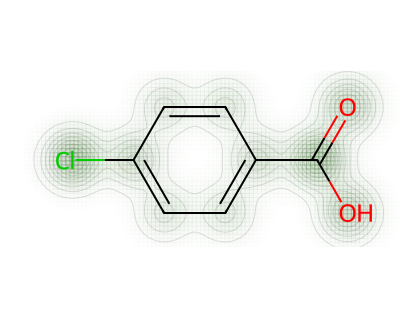

In [15]:
from IPython.display import SVG
from qsarkit.explainability import draw_atom_weights

SVG(draw_atom_weights(target, atom_weights, size=(420, 320)))

The standard cheminformatics depiction: RDKit's similarity map, with
positive contributions in one colour and negative in the other.

Note that symmetry-equivalent atoms carry identical weights — that is a
correctness check on the mapping, not a coincidence. And flat weights
across a ring mean no single atom is *necessary*, because the others set
the same bits; read it as "this ring matters as a unit".

With SHAP or LIME installed the same mapper takes their output directly:

```python
from qsarkit.explainability import SHAPExplainer

explainer = SHAPExplainer(regressor)              # pip install qsarkit[explainability]
weights = mapper.from_shap(target, explainer, X[r_test], index=0)
```

## Shipping the model

Not pickle. A pickled model embeds the exact class layout of every object,
so a file written under one scikit-learn release can fail to load — or load
into a subtly different object — under the next; and loading one executes
arbitrary code.

In [16]:
import os
import tempfile
from qsarkit.persistence import ModelMetadata, inspect_bundle, load_model, save_model

path = save_model(
    fitted,
    os.path.join(tempfile.mkdtemp(), "benzoic_acid_pIC50"),
    pipeline=fingerprint,                 # so the bundle can take molecules
    metadata=ModelMetadata(
        name="benzoic acid series pIC50",
        endpoint="pIC50 (-log10 M)",
        task="regression",
        n_training_samples=len(Y),
        description="Random forest on Morgan ECFP4, 512 bits.",
        extra={"validation": f"6-fold CV, Q2 = {cv['q2']:.3f}"},
    ),
)
print("wrote:", path)
print("files:", sorted(p.name for p in __import__("pathlib").Path(path).iterdir()))

wrote: /var/folders/wm/97yp1n4j7yq8_zfhb7tfnpkc0000gn/T/tmpv2gzlph7/benzoic_acid_pIC50.qsar
files: ['estimator.skops', 'manifest.json', 'metadata.json', 'pipeline.skops']


Everything but the estimator is plain JSON, readable without importing
qsarkit at all — which is what makes the bundle still interpretable when
the library has moved on.

In [17]:
import json, pathlib

print(json.dumps(json.loads((pathlib.Path(path) / "metadata.json").read_text()),
                 indent=2)[:700])

{
  "created": "2026-09-25T02:00:20+00:00",
  "description": "Random forest on Morgan ECFP4, 512 bits.",
  "endpoint": "pIC50 (-log10 M)",
  "environment": {
    "numpy": "2.3.5",
    "platform": "Darwin",
    "python": "3.13.9",
    "qsarkit": "0.3.0",
    "rdkit": "2025.09.3",
    "scikit-learn": "1.8.0",
    "scipy": "1.16.3"
  },
  "extra": {
    "validation": "6-fold CV, Q2 = 0.694"
  },
  "feature_names": null,
  "format_version": "1",
  "n_features": 512,
  "n_training_samples": 24,
  "name": "benzoic acid series pIC50",
  "qsarkit_version": "0.3.0",
  "task": "regression"
}


### Inspect before you load

The safe first step with a model from someone else: report what the bundle
contains without executing any of it.

In [18]:
report = inspect_bundle(path)
print("estimator:", report["manifest"]["estimator_class"])
print("pipeline: ", report["manifest"]["pipeline_class"])
print("third-party types needing your approval:", report["untrusted"])

estimator: qsarkit.models._facades.QSARRegressor
pipeline:  qsarkit.representation.fingerprints._morgan.MorganFingerprint
third-party types needing your approval: []


`untrusted` lists types skops would need permission to build. qsarkit's own
classes are trusted automatically — no more dangerous than `import qsarkit`,
since the class comes from the installed package and the file supplies only
attribute values. Anything else you must recognize and name.

In [19]:
bundle = load_model(path)
print(bundle)
# Straight from structures, because the transformer travelled with it.
print("predictions:", bundle.predict_mols(mols[:4]).round(3))
print("identical to the original:",
      np.allclose(bundle.predict_mols(mols), fitted.predict(X)))

<ModelBundle 'benzoic acid series pIC50' (regression, 512 features, pipeline: MorganFingerprint)>
predictions: [5.448 5.538 7.016 5.587]
identical to the original: True


### The guardrails

A feature-width mismatch is the failure that otherwise produces confident
nonsense, so it is refused.

In [20]:
try:
    bundle.predict(np.zeros((2, 64)))
except ValueError as exc:
    print("refused:", exc)

refused: This model expects 512 features but was given 64. The representation used at prediction time must match the one used for training -- check the fingerprint size and radius, or use predict_mols() with the stored pipeline.


In [21]:
import os
import tempfile
from qsarkit.persistence import ModelMetadata, inspect_bundle, load_model, save_model

path = save_model(
    fitted,
    os.path.join(tempfile.mkdtemp(), "benzoic_acid_pIC50"),
    pipeline=fingerprint,                 # so the bundle can take molecules
    metadata=ModelMetadata(
        name="benzoic acid series pIC50",
        endpoint="pIC50 (-log10 M)",
        task="regression",
        n_training_samples=len(Y),
        description="Random forest on Morgan ECFP4, 512 bits.",
        extra={"validation": f"6-fold CV, Q2 = {cv['q2']:.3f}"},
    ),
)
print("wrote:", path)
print("files:", sorted(p.name for p in __import__("pathlib").Path(path).iterdir()))

wrote: /var/folders/wm/97yp1n4j7yq8_zfhb7tfnpkc0000gn/T/tmpl132rlfb/benzoic_acid_pIC50.qsar
files: ['estimator.skops', 'manifest.json', 'metadata.json', 'pipeline.skops']


## The report

Everything above, in the document a reviewer reads — as text, Markdown,
HTML, JSON or PDF.

In [22]:
from qsarkit.metrics import qsar_regression_report
from qsarkit.reporting import QSARReport, plot_predicted_vs_observed

report_doc = (
    QSARReport(title="Benzoic acid series — pIC50", endpoint="pIC50 (-log10 M)",
               author="qsarkit example")
    .add_dataset_section(n_compounds=len(mols), source="Synthetic example series")
    .add_model_section(fitted, descriptors="Morgan ECFP4, 512 bits")
    .add_validation_section(
        qsar_regression_report(Y, predictions),
        figures=[plot_predicted_vs_observed(Y, predictions)],
    )
    .add_section(
        "Residual diagnostics",
        content={k: round(v, 4) if isinstance(v, float) else v
                 for k, v in diag.items()},
        text="Cross-validated out-of-fold residuals. Read the shape terms "
             "rather than the Shapiro-Wilk p-value at this sample size.",
    )
)
print(report_doc.to_text(width=72)[:1100])

Benzoic acid series — pIC50
Endpoint: pIC50 (-log10 M)
Author: qsarkit example
Created: 2026-09-25T02:00:23+00:00

Dataset
------------------------------------------------------------------------
  n_compounds  24
  source       Synthetic example series

Algorithm
------------------------------------------------------------------------
  algorithm             QSARRegressor
  descriptors           Morgan ECFP4, 512 bits
  param.fit_params      n/a
  param.model_args      n/a
  param.model_params    n/a
  param.name            rf
  param.predict_params  n/a
  param.random_state    0

Validation
------------------------------------------------------------------------
  r2                 0.6939
  rmse               0.5943
  mae                0.4332
  ccc                0.7876
  q2_f2              0.6939
  average_r2m        0.4333
  delta_r2m          0.3262
  golbraikh_tropsha  r2=0.7353; r0_squared=0.3352; r0_prime_squared=0.6996; k=0.981; 


In [23]:
out = os.path.join(tempfile.mkdtemp(), "report.pdf")
try:
    report_doc.to_pdf(out, include_figures=False)   # figures need kaleido
    print("PDF written:", os.path.getsize(out), "bytes")
except Exception as exc:
    print(type(exc).__name__, exc)

PDF written: 4027 bytes


## What this notebook showed

1. **Accuracy lies on imbalanced data.** 92% by predicting nothing. Use MCC
   or balanced accuracy.
2. **Balance the training set, in the right space.** SMOTE belongs after
   featurization, and costs you the molecules.
3. **0.5 is an arbitrary constant.** Choose the threshold against a stated
   objective — and on validation data.
4. **An excellent AUC says nothing about the probabilities.** Check
   calibration before you threshold or combine them.
5. **Check your residuals.** Every regression metric assumes a shape your
   data may not have.
6. **Explain on the molecule, and report the collision rate**, so the
   picture's honesty is visible.
7. **Do not pickle a model you intend to keep.** Save provenance beside it,
   and make a stranger's bundle inspectable before it runs.